# **EE 413: Applied Digital Signal Processing**

##*Project: Audio Signal Classification*

**Dataset:** *Free-Spoken Digit Dataset (FSDD)*

https://github.com/Jakobovski/free-spoken-digit-dataset

**Application of course topics:**

Topic 1: Signals and System Review

Topic 2: Discrete Fourier Transform and Short Time Fourier Transform Applications

Topic 3: Wavelet Transform

##**Team Members:**

- Member 1 - ID
- Ahmad Edrees Al-Eid - 20215490
- Member 3 - ID
- Member 4 - ID




---



## 1- Data Preprocessing





### Libraries and Tools

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import hilbert
from scipy.signal import butter, filtfilt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
from sklearn.neighbors import KNeighborsClassifier
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
import ipywidgets as widgets
from matplotlib.colors import LogNorm, Normalize
from IPython.display import display
from scipy import signal, interpolate
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import librosa
import librosa.display
import librosa.feature
import librosa.util
import librosa.effects
from scipy import interpolate
from scipy.io import wavfile as wav

### Data Loading

In [ ]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

dataset_path = Path("free-spoken-digit-dataset/recordings")
wav_files = sorted(dataset_path.glob("*.wav"))

signals = []
labels = []
file_names = []

for file in wav_files:
    y, sr = librosa.load(file, sr=8000, mono=True)
    signals.append(y)

    label = file.stem.split("_")[0]
    labels.append(label)

    file_names.append(file.name)

print("Total files loaded:", len(signals))
print("Example:", file_names[50], "Digit:", labels[0])
N = len(y)

print("Loaded audio path:", audio_path)
print("Sampling rate (Hz):", sr)
print("Number of samples:", N)

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.
Total files loaded: 3000
Example: 0_jackson_0.wav Digit: 0
Loaded audio path: free-spoken-digit-dataset/recordings/0_george_0.wav
Sampling rate (Hz): 8000
Number of samples: 3507




---



## 2- Time Domain Analysis



---



## 3- DFT Analysis



---



## 4- STFT Analysis

*   Implement STFT-based analysis



In [ ]:
def perform_stft_analysis(signal, sr, label, file_name):

    n_fft = 256
    win_length = 256
    hop_length = 128
    window = "hann"

    # STFT
    D = librosa.stft(signal, n_fft=n_fft,win_length=win_length,hop_length=hop_length,window=window)

    S = np.abs(D)

    # Features
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr,n_fft=n_fft,hop_length=hop_length)[0]

    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length)[0]

    rms = librosa.feature.rms(y=signal,frame_length=win_length,hop_length=hop_length)[0]

    zcr = librosa.feature.zero_crossing_rate(signal, frame_length=win_length,hop_length=hop_length)[0]

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=10, n_fft=n_fft,hop_length=hop_length)

    print("--- STFT Feature Extraction ---")
    print("File:", file_name)
    print("Digit:", label)
    print(f"Spectral Centroid Mean = {np.mean(centroid):.4f}")
    print(f"Spectral Bandwidth Mean = {np.mean(bandwidth):.4f}")
    print(f"RMS Energy Mean = {np.mean(rms):.4f}")
    print(f"Zero Crossing Rate Mean = {np.mean(zcr):.4f}")
    print(f"MFCC Mean = {np.mean(mfcc):.4f}")

    # Plot waveform + STFT
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    librosa.display.waveshow(signal, sr=sr, color="blue")
    plt.title(f"Time-Domain Signal: {file_name}")
    plt.ylabel("Amplitude")

    plt.subplot(2, 1, 2)
    librosa.display.specshow(S,
                             sr=sr,
                             hop_length=hop_length,
                             x_axis="time",
                             y_axis="hz",
                             cmap="inferno")
    plt.title("STFT Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude")

    plt.tight_layout()
    plt.show()

--- STFT Feature Extraction ---
File: 0_jackson_0.wav
Digit: 0
Spectral Centroid Mean = 671.2036
Spectral Bandwidth Mean = 706.5476
RMS Energy Mean = 0.1074
Zero Crossing Rate Mean = 0.0939
MFCC Mean = -35.8490


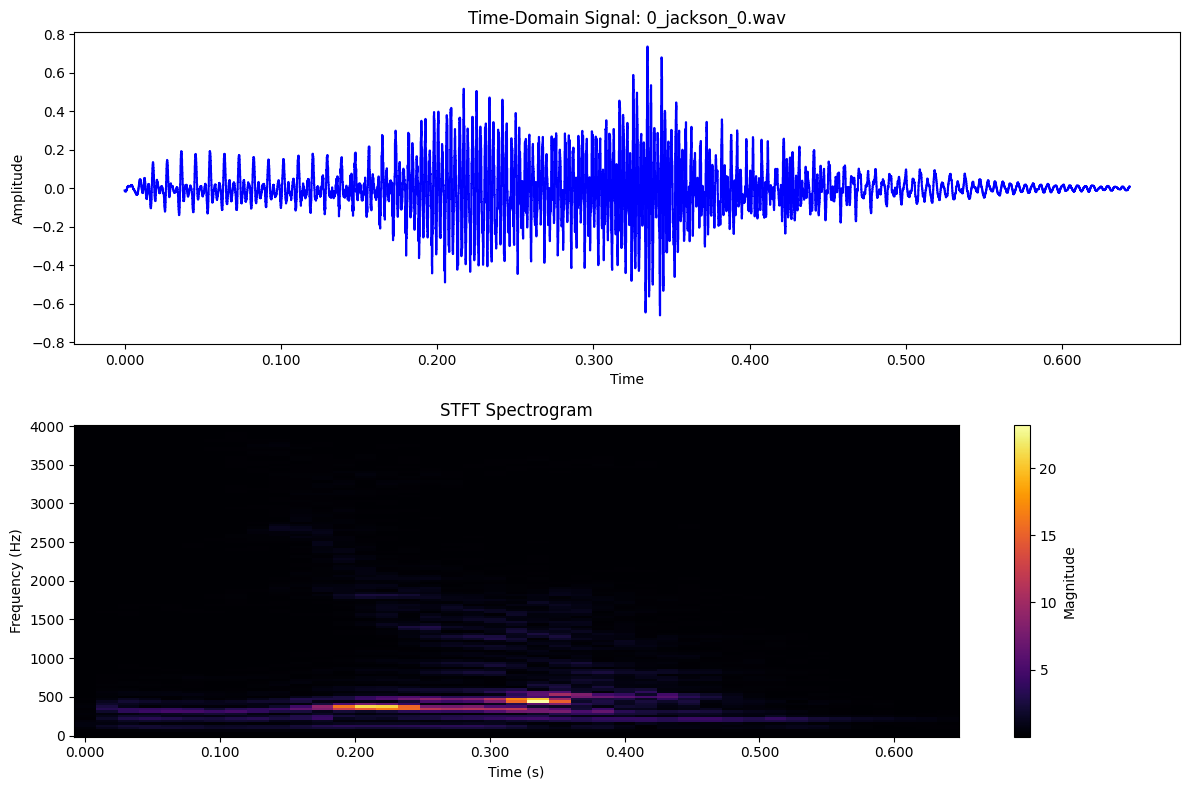

In [ ]:
i = 50  # it is 3000 file so we can put i fromn 0 to 3000 and it will shows its anallysis

perform_stft_analysis(signals[i], sr, labels[i], file_names[i])



*   Extract short-time spectral features







In [ ]:
rows = []

n_fft = 256
win_length = 256
hop_length = 128
window = "hann"

for i in range(len(signals)):

    signal = signals[i]
    label = labels[i]
    file_name = file_names[i]

    centroid_stft = librosa.feature.spectral_centroid(y=signal, sr=sr, n_fft=n_fft,hop_length=hop_length)[0]

    bandwidth_stft = librosa.feature.spectral_bandwidth(y=signal, sr=sr, n_fft=n_fft,hop_length=hop_length)[0]

    rms_stft = librosa.feature.rms(y=signal, frame_length=win_length,hop_length=hop_length)[0]

    zcr_stft = librosa.feature.zero_crossing_rate(signal, frame_length=win_length, hop_length=hop_length)[0]

    mfcc_stft = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=10, n_fft=n_fft,hop_length=hop_length)

    rows.append({
        "file_name": file_name,
        "digit": label,
        "centroid_mean": np.mean(centroid_stft),
        "bandwidth_mean": np.mean(bandwidth_stft),
        "rms_mean": np.mean(rms_stft),
        "zcr_mean": np.mean(zcr_stft),
        "mfcc_mean": np.mean(mfcc_stft)
    })

df = pd.DataFrame(rows)

df.head()

,file_name,digit,centroid_mean,bandwidth_mean,rms_mean,zcr_mean,mfcc_mean
0,0_george_0.wav,0,1218.775867,1037.495717,0.082450,0.153988,-49.402805
1,0_george_1.wav,0,949.313851,939.690747,0.042231,0.121516,-54.555733
2,0_george_10.wav,0,1202.351591,971.387757,0.030590,0.203042,-61.680344
3,0_george_11.wav,0,1110.154187,984.098051,0.039367,0.159617,-56.678474
4,0_george_12.wav,0,1036.213227,941.089771,0.039620,0.156006,-54.587471


In [ ]:
digit_summary = df.groupby("digit").mean(numeric_only=True)

digit_summary

,centroid_mean,bandwidth_mean,rms_mean,zcr_mean,mfcc_mean
digit,,,,,
0,942.164725,898.500377,0.040555,0.145410,-37.961933
1,910.427607,876.925496,0.034320,0.146012,-39.358593
2,1070.908861,935.162590,0.031781,0.184378,-41.392460
3,1157.175087,1045.291129,0.034176,0.180462,-39.926842
4,910.255093,766.041492,0.046540,0.168975,-39.190521
5,1169.313107,919.989794,0.039242,0.220352,-38.476086
6,1624.727543,1114.136505,0.023943,0.341738,-44.041401
7,1165.922845,985.615861,0.030029,0.207554,-39.815018
8,1365.135458,1122.666959,0.035047,0.227063,-41.578808




*   Study effects of window type, window length, and overlap




Window type comparison

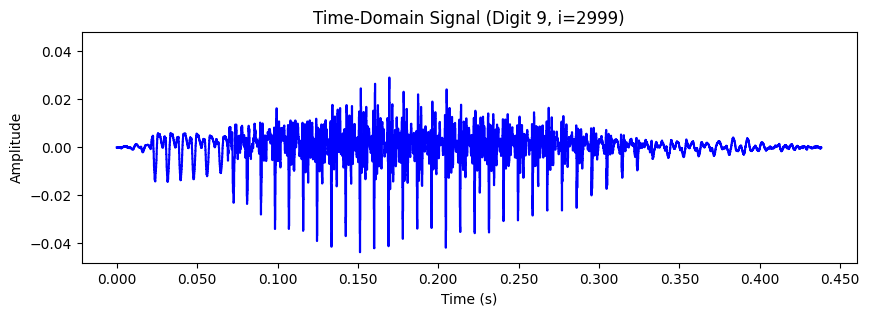

In [ ]:
i = 2999

y = signals[i]
label = labels[i]

plt.figure(figsize=(10,3))

librosa.display.waveshow(y, sr=sr, color='blue')

plt.title(f"Time-Domain Signal (Digit {label}, i={i})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

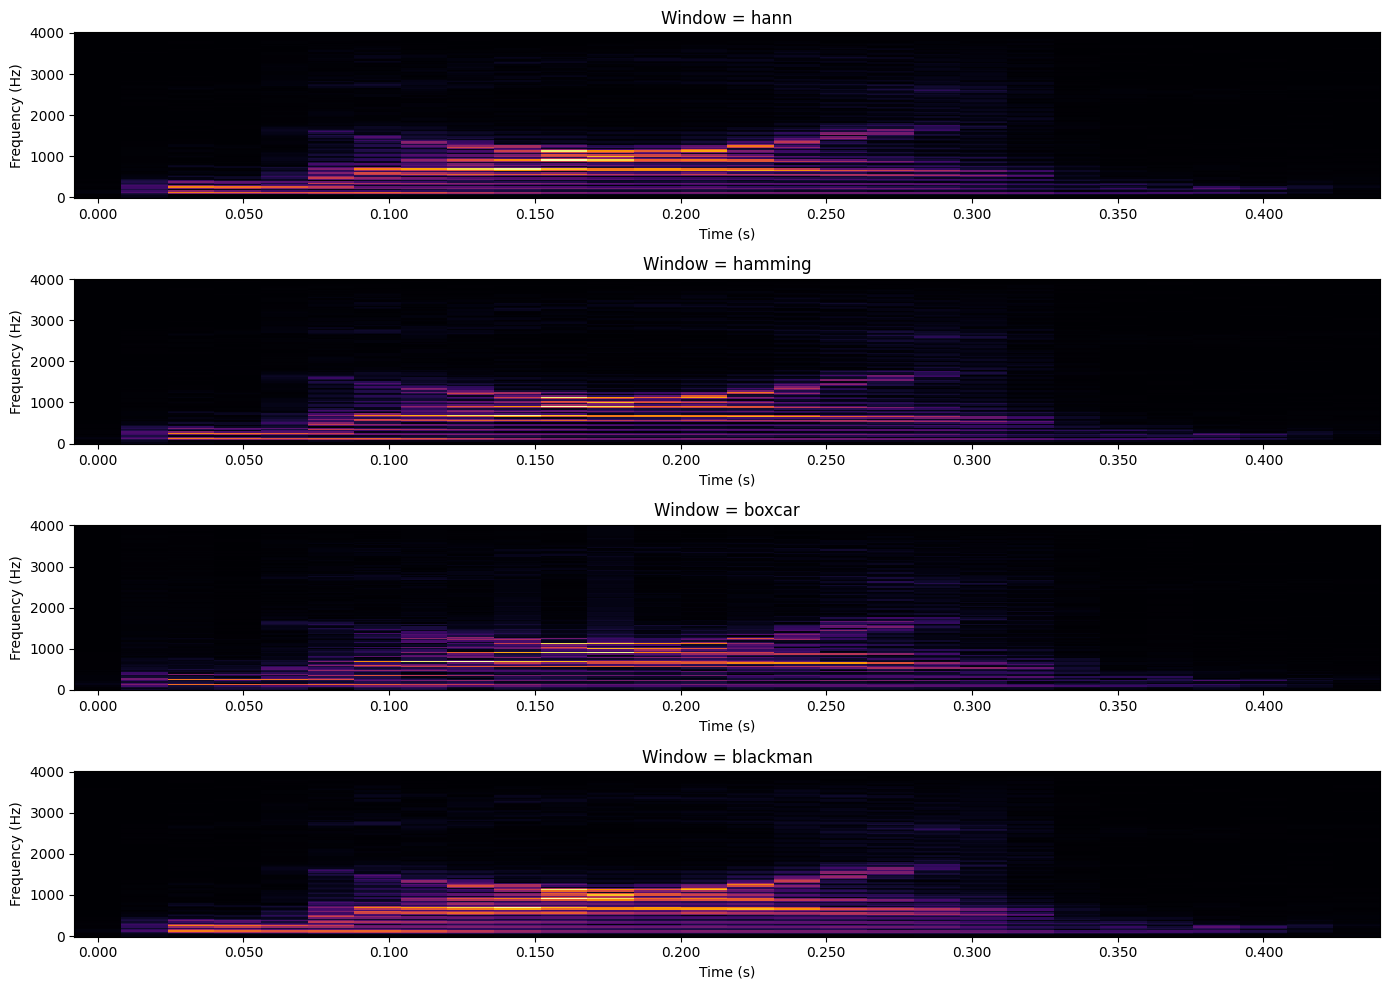

In [ ]:
windows = ["hann", "hamming", "boxcar", "blackman"]

i = 2999
signal = signals[i]

plt.figure(figsize=(14, 10))

for index, w in enumerate(windows):

    D = librosa.stft(signal,n_fft=256, win_length=256, hop_length=128,window=w)

    S = np.abs(D)

    plt.subplot(4, 1, index + 1)
    librosa.display.specshow(S, sr=sr, hop_length=128,x_axis="time", y_axis="hz",cmap="inferno")
    plt.title(f"Window = {w}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

Window length comparison

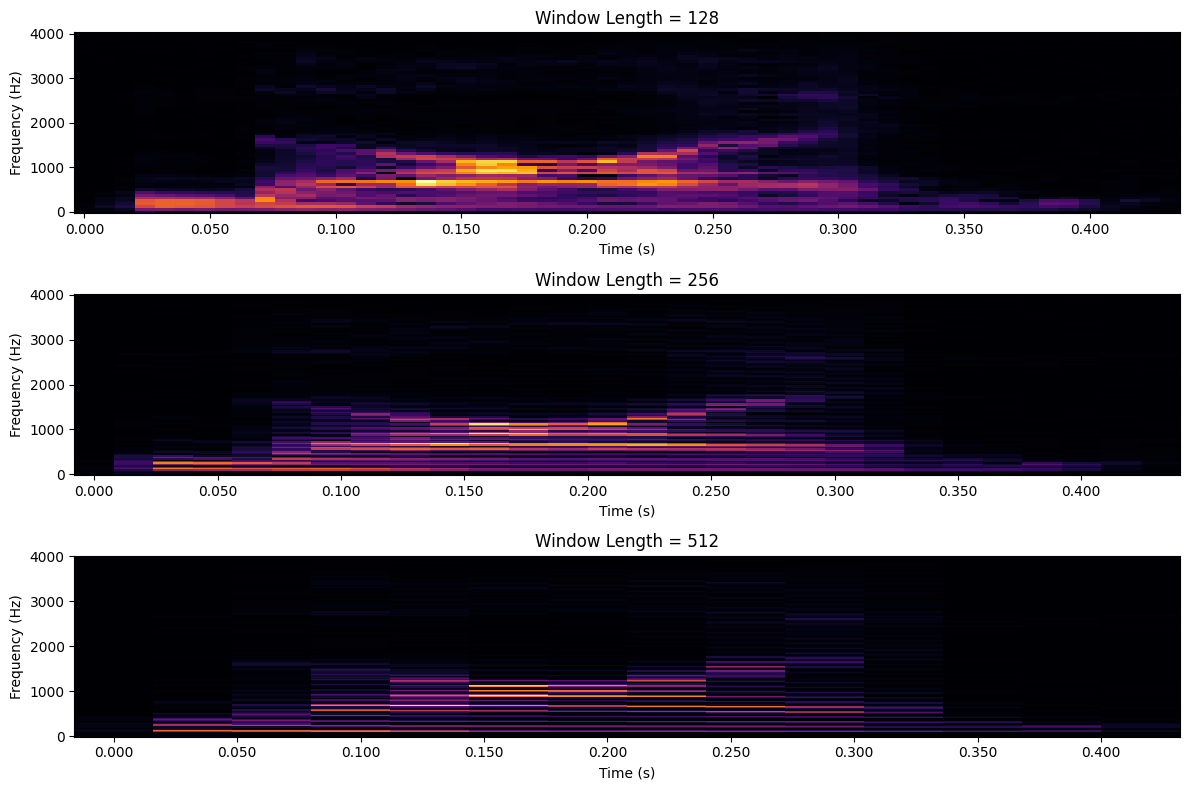

In [ ]:
lengths = [128, 256, 512]

i = 2999
signal = signals[i]

plt.figure(figsize=(12, 8))

for index, L in enumerate(lengths):

    D = librosa.stft(signal, n_fft=L, win_length=L,hop_length=L//2,window="hann")

    S = np.abs(D)

    plt.subplot(3, 1, index + 1)
    librosa.display.specshow(S,sr=sr, hop_length=L//2, x_axis="time",y_axis="hz", cmap="inferno")

    plt.title(f"Window Length = {L}")

    plt.xlabel("Time (s)")

    plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

Overlap comparison

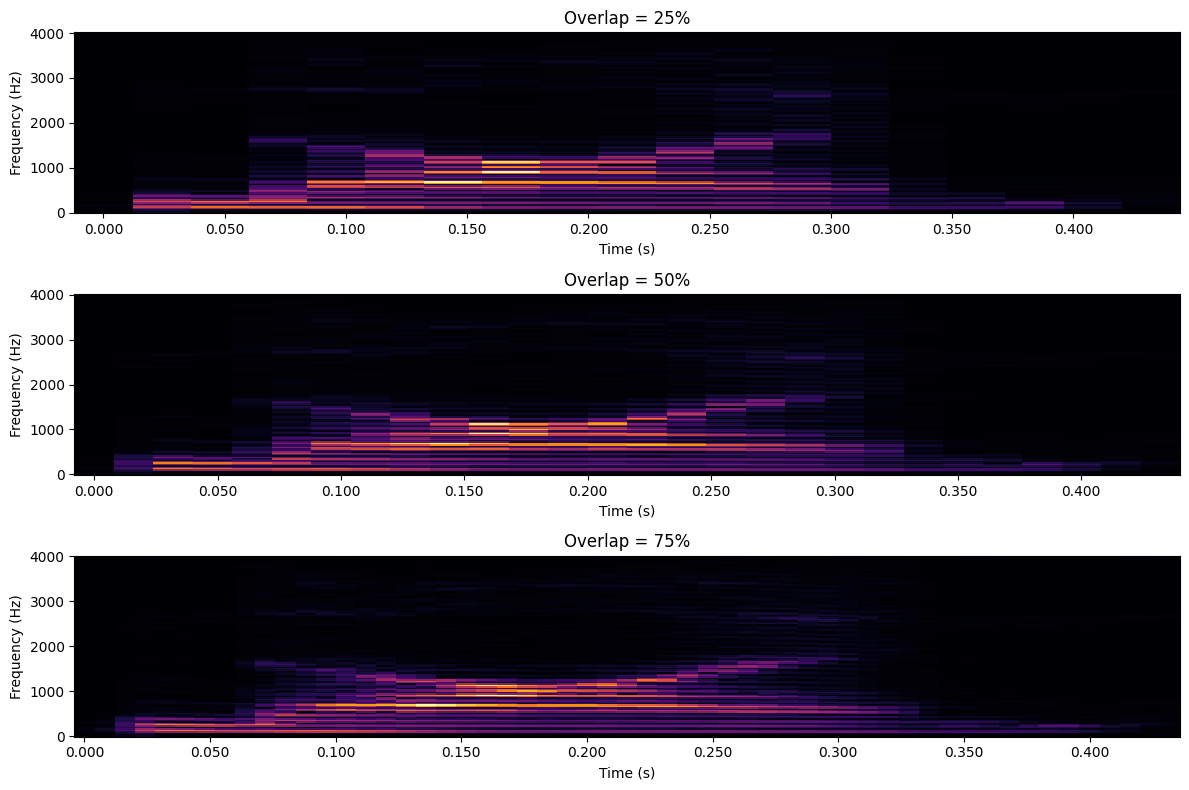

In [ ]:
hop_values = [192, 128, 64]  # 25%, 50%, 75%

i = 2999
signal = signals[i]

plt.figure(figsize=(12, 8))

for index, hop in enumerate(hop_values):

    overlap = (1 - hop / 256) * 100

    D = librosa.stft(signal, n_fft=256, win_length=256, hop_length=hop,window="hann")

    S = np.abs(D)

    plt.subplot(3, 1, index + 1)
    librosa.display.specshow(S, sr=sr, hop_length=hop,x_axis="time",  y_axis="hz", cmap="inferno")

    plt.title(f"Overlap = {overlap:.0f}%")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()



---



## 5- Wavelet Analysis



---



## 6- Featrue Classification